In [6]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from wordcloud import STOPWORDS

warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Constants 
OCULA_MAP = {
    "HATE": "hate",
    "OFFN": "offensive",
    "PRFN": "offensive",
    "NONE": "normal",
}
CLASS_COLORS = {"hate": "#E74C3C", "offensive": "#F39C12", "normal": "#2ECC71"}
OCULA_ORDER  = ["hate", "offensive", "normal"]
TASK2_ORDER  = ["HATE", "OFFN", "PRFN", "NONE"]
PLOT_DIR     = "./plots/hasoc"
os.makedirs(PLOT_DIR, exist_ok=True)

STOPWORDS.update([
    "the","a","an","is","it","in","on","at","to","of","and","or",
    "but","not","s","t","rt","http","https","co","amp","gt","lt",
    "via","we","i","you","he","she","they","was","are","be","for",
    "this","that","with","have","from","do","my","your","me","as",
])

print("Imports complete")

Imports complete


In [5]:
#  Load both TSV files 
en_path = "../data/raw/hasoc_2019_english.tsv"
hi_path = "../data/raw/hasoc_2019_hindi.tsv"

en = pd.read_csv(en_path, sep="\t")
hi = pd.read_csv(hi_path, sep="\t")

print(f"English : {len(en):,} rows  | columns: {list(en.columns)}")
print(f"Hindi   : {len(hi):,} rows  | columns: {list(hi.columns)}")
en.head(3)

English : 5,852 rows  | columns: ['text_id', 'text', 'task_1', 'task_2', 'task_3']
Hindi   : 4,665 rows  | columns: ['text_id', 'text', 'task_1', 'task_2', 'task_3']


,text_id,text,task_1,task_2,task_3
0,hasoc_en_1,#DhoniKeepsTheGlove | WATCH: Sports Minister K...,NOT,NONE,NONE
1,hasoc_en_2,@politico No. We should remember very clearly ...,HOF,HATE,TIN
2,hasoc_en_3,@cricketworldcup Guess who would be the winner...,NOT,NONE,NONE


In [7]:
def add_features(df, lang_code):
    df = df.copy()
    df["word_count"]     = df["text"].astype(str).str.split().str.len()
    df["char_count"]     = df["text"].astype(str).str.len()
    df["ocula_label"]    = df["task_2"].map(OCULA_MAP)
    df["lang"]           = lang_code
    # Devanagari: Unicode block U+0900–U+097F
    df["has_devanagari"] = df["text"].astype(str).apply(
        lambda t: bool(re.search(r"[\u0900-\u097F]", t))
    )
    return df

en = add_features(en, "en")
hi = add_features(hi, "hi")

print("English sample:")
print(en[["text","task_1","task_2","ocula_label","word_count","has_devanagari"]].head(3))
print("\nHindi sample:")
print(hi[["text","task_1","task_2","ocula_label","word_count","has_devanagari"]].head(3))

English sample:
                                                text task_1 task_2  \
0  #DhoniKeepsTheGlove | WATCH: Sports Minister K...    NOT   NONE   
1  @politico No. We should remember very clearly ...    HOF   HATE   
2  @cricketworldcup Guess who would be the winner...    NOT   NONE   

  ocula_label  word_count  has_devanagari  
0      normal          36           False  
1        hate          17           False  
2      normal          23           False  

Hindi sample:
                                                text task_1 task_2  \
0  बांग्लादेश की शानदार वापसी, भारत को 314 रन पर ...    NOT   NONE   
1  सब रंडी नाच देखने मे व्यस्त जैसे ही कोई #शांती...    HOF   PRFN   
2  तुम जैसे हरामियों के लिए बस जूतों की कमी है शु...    HOF   PRFN   

  ocula_label  word_count  has_devanagari  
0      normal          12            True  
1   offensive          19            True  
2   offensive          58            True  



English — task_2 counts:
  HATE  : 1,143  (19.5%)
  OFFN  :   451  (7.7%)
  PRFN  :   667  (11.4%)
  NONE  : 3,591  (61.4%)

Hindi — task_2 counts:
  HATE  :   556  (11.9%)
  OFFN  :   676  (14.5%)
  PRFN  : 1,237  (26.5%)
  NONE  : 2,196  (47.1%)


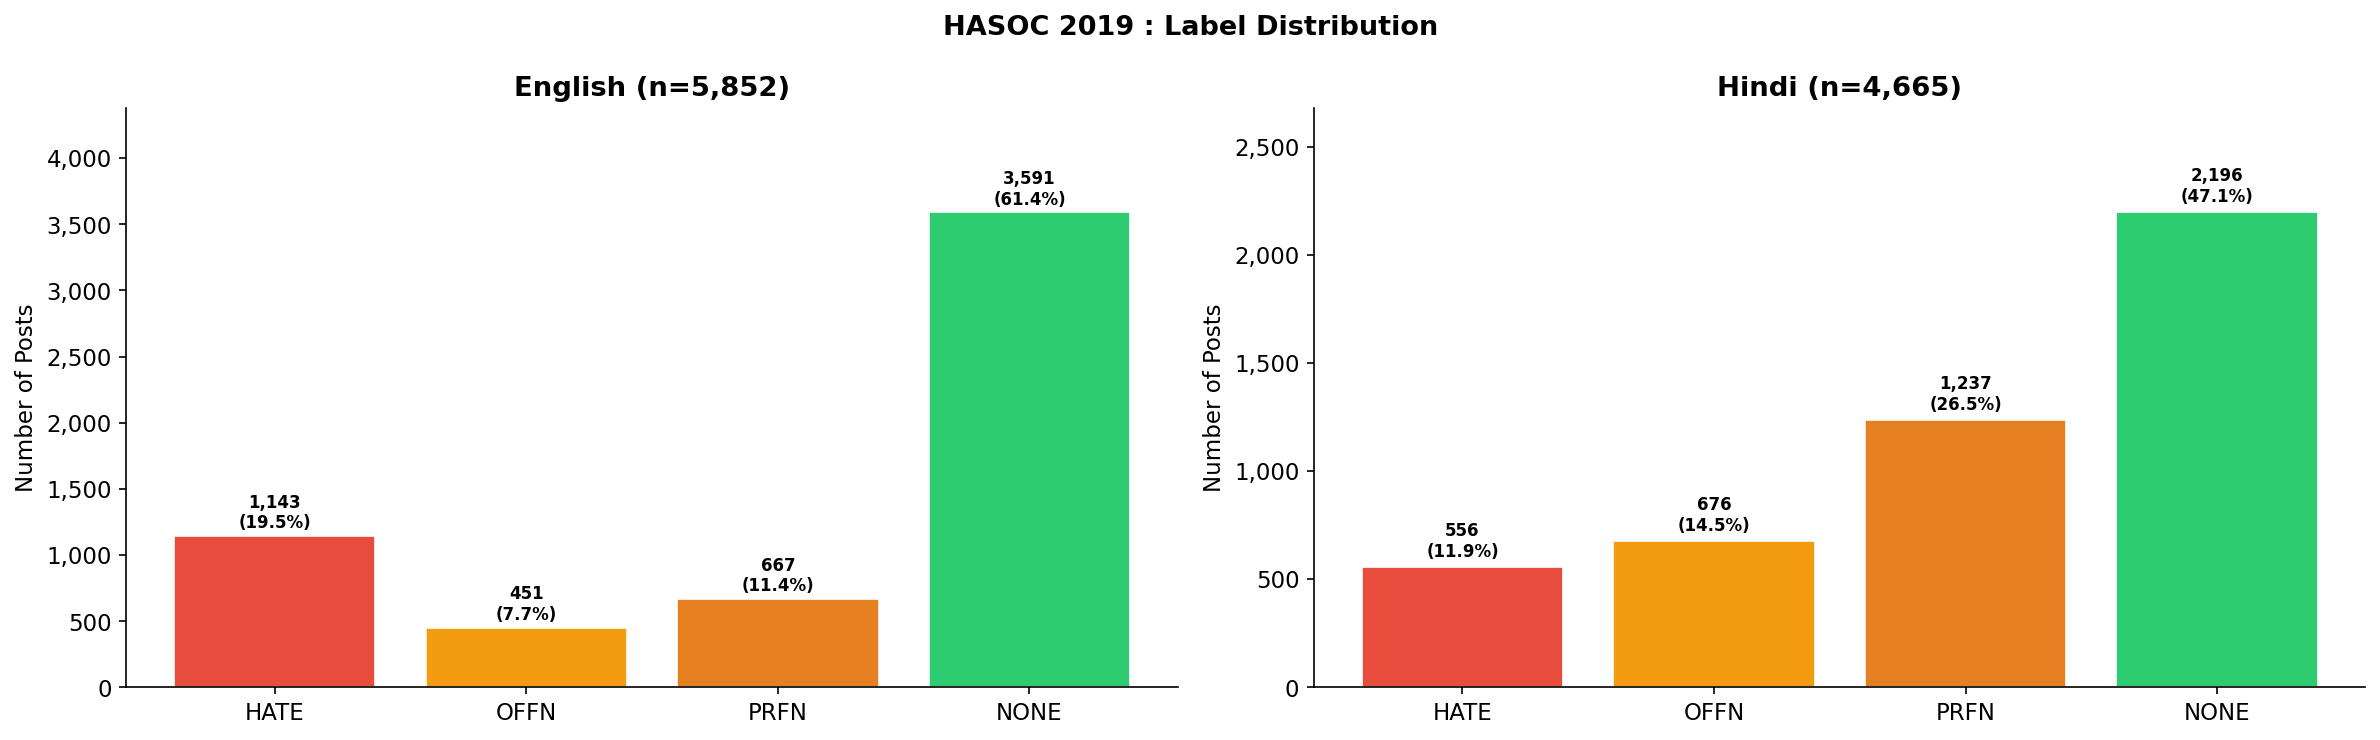

✓ Saved 01_task2_distribution.png


In [13]:
# ── Print counts ──────────────────────────────────────────────────────────────
for name, df in [("English", en), ("Hindi", hi)]:
    print(f"\n{name} — task_2 counts:")
    vc = df["task_2"].value_counts()
    for lbl in TASK2_ORDER:
        cnt = vc.get(lbl, 0)
        print(f"  {lbl:6s}: {cnt:5,}  ({cnt/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("HASOC 2019 : Label Distribution", fontsize=13, fontweight="bold")

task2_colors = {"HATE": "#E74C3C", "OFFN": "#F39C12", "PRFN": "#E67E22", "NONE": "#2ECC71"}

for ax, (name, df) in zip(axes, [("English", en), ("Hindi", hi)]):
    vc = df["task_2"].value_counts().reindex(TASK2_ORDER, fill_value=0)
    colors = [task2_colors[l] for l in TASK2_ORDER]
    bars = ax.bar(TASK2_ORDER, vc.values, color=colors, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{v:,}\n({v/len(df)*100:.1f}%)",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(f"{name} (n={len(df):,})", fontweight="bold")
    ax.set_ylabel("Number of Posts")
    ax.set_ylim(0, vc.max() * 1.22)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/01_task2_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved 01_task2_distribution.png")

In [15]:
# ── PRFN collapse explanation 
prfn_en = (en["task_2"] == "PRFN").sum()
prfn_hi = (hi["task_2"] == "PRFN").sum()
print("Bridge mapping: task_2 → OCULA label")
print("  HATE → hate  |  OFFN → offensive  |  PRFN → offensive  |  NONE → normal")
print(f"\nPRFN collapsed into 'offensive':")
print(f"  English PRFN: {prfn_en:,}  ({prfn_en/len(en)*100:.1f}% of EN corpus)")
print(f"  Hindi   PRFN: {prfn_hi:,}  ({prfn_hi/len(hi)*100:.1f}% of HI corpus)")


for name, df in [("English", en), ("Hindi", hi)]:
    print(f"\n{name} — OCULA label counts:")
    vc = df["ocula_label"].value_counts()
    for lbl in OCULA_ORDER:
        cnt = vc.get(lbl, 0)
        print(f"  {lbl:12s}: {cnt:5,}  ({cnt/len(df)*100:.1f}%)")

Bridge mapping: task_2 → OCULA label
  HATE → hate  |  OFFN → offensive  |  PRFN → offensive  |  NONE → normal

PRFN collapsed into 'offensive':
  English PRFN: 667  (11.4% of EN corpus)
  Hindi   PRFN: 1,237  (26.5% of HI corpus)

English — OCULA label counts:
  hate        : 1,143  (19.5%)
  offensive   : 1,118  (19.1%)
  normal      : 3,591  (61.4%)

Hindi — OCULA label counts:
  hate        :   556  (11.9%)
  offensive   : 1,913  (41.0%)
  normal      : 2,196  (47.1%)


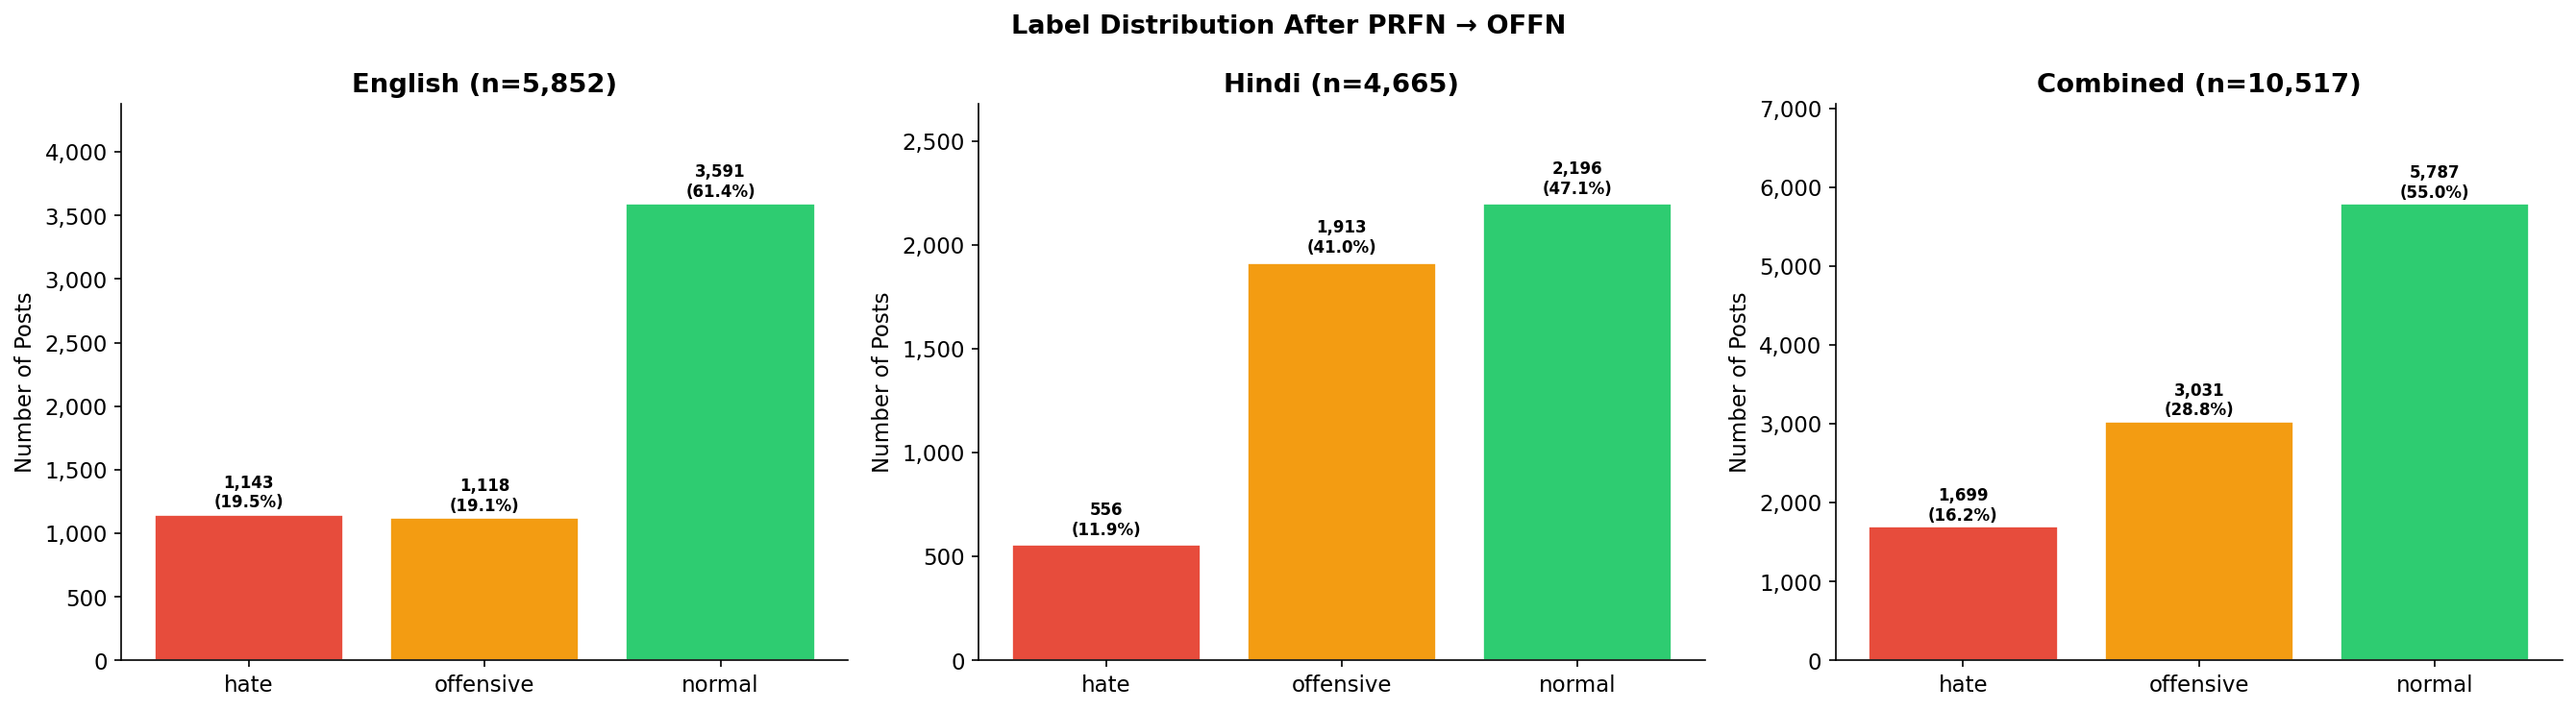

✓ Saved 02_ocula_label_distribution.png


In [23]:
combined = pd.concat([en, hi], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Label Distribution After PRFN → OFFN", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, [("English", en), ("Hindi", hi), ("Combined", combined)]):
    vc = df["ocula_label"].value_counts().reindex(OCULA_ORDER, fill_value=0)
    colors = [CLASS_COLORS[l] for l in OCULA_ORDER]
    bars = ax.bar(OCULA_ORDER, vc.values, color=colors, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{v:,}\n({v/len(df)*100:.1f}%)",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(f"{name} (n={len(df):,})", fontweight="bold")
    ax.set_ylabel("Number of Posts")
    ax.set_ylim(0, vc.max() * 1.22)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_ocula_label_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved 02_ocula_label_distribution.png")

In [18]:
def classify_script(text):
    text = str(text)
    has_deva  = bool(re.search(r"[\u0900-\u097F]", text))
    has_latin = bool(re.search(r"[a-zA-Z]", text))
    if has_deva and has_latin:
        return "Mixed"
    elif has_deva:
        return "Devanagari"
    else:
        return "Romanized"

hi["script_type"] = hi["text"].apply(classify_script)

script_counts = hi["script_type"].value_counts()
total_hi = len(hi)

print("Hindi script distribution:")
for stype in ["Devanagari", "Romanized", "Mixed"]:
    cnt = script_counts.get(stype, 0)
    print(f"  {stype:12s}: {cnt:5,}  ({cnt/total_hi*100:.1f}%)")

Hindi script distribution:
  Devanagari  : 2,428  (52.0%)
  Romanized   :   300  (6.4%)
  Mixed       : 1,937  (41.5%)


In [20]:
# ── Print mean word count 
for name, df in [("English", en), ("Hindi", hi)]:
    print(f"\n{name} — mean word count per OCULA label:")
    for lbl in OCULA_ORDER:
        sub = df[df["ocula_label"] == lbl]["word_count"]
        print(f"  {lbl:12s}: mean={sub.mean():.1f}  median={sub.median():.1f}")


English — mean word count per OCULA label:
  hate        : mean=25.5  median=24.0
  offensive   : mean=24.1  median=22.0
  normal      : mean=23.2  median=21.0

Hindi — mean word count per OCULA label:
  hate        : mean=33.8  median=31.0
  offensive   : mean=26.1  median=22.0
  normal      : mean=27.9  median=24.0


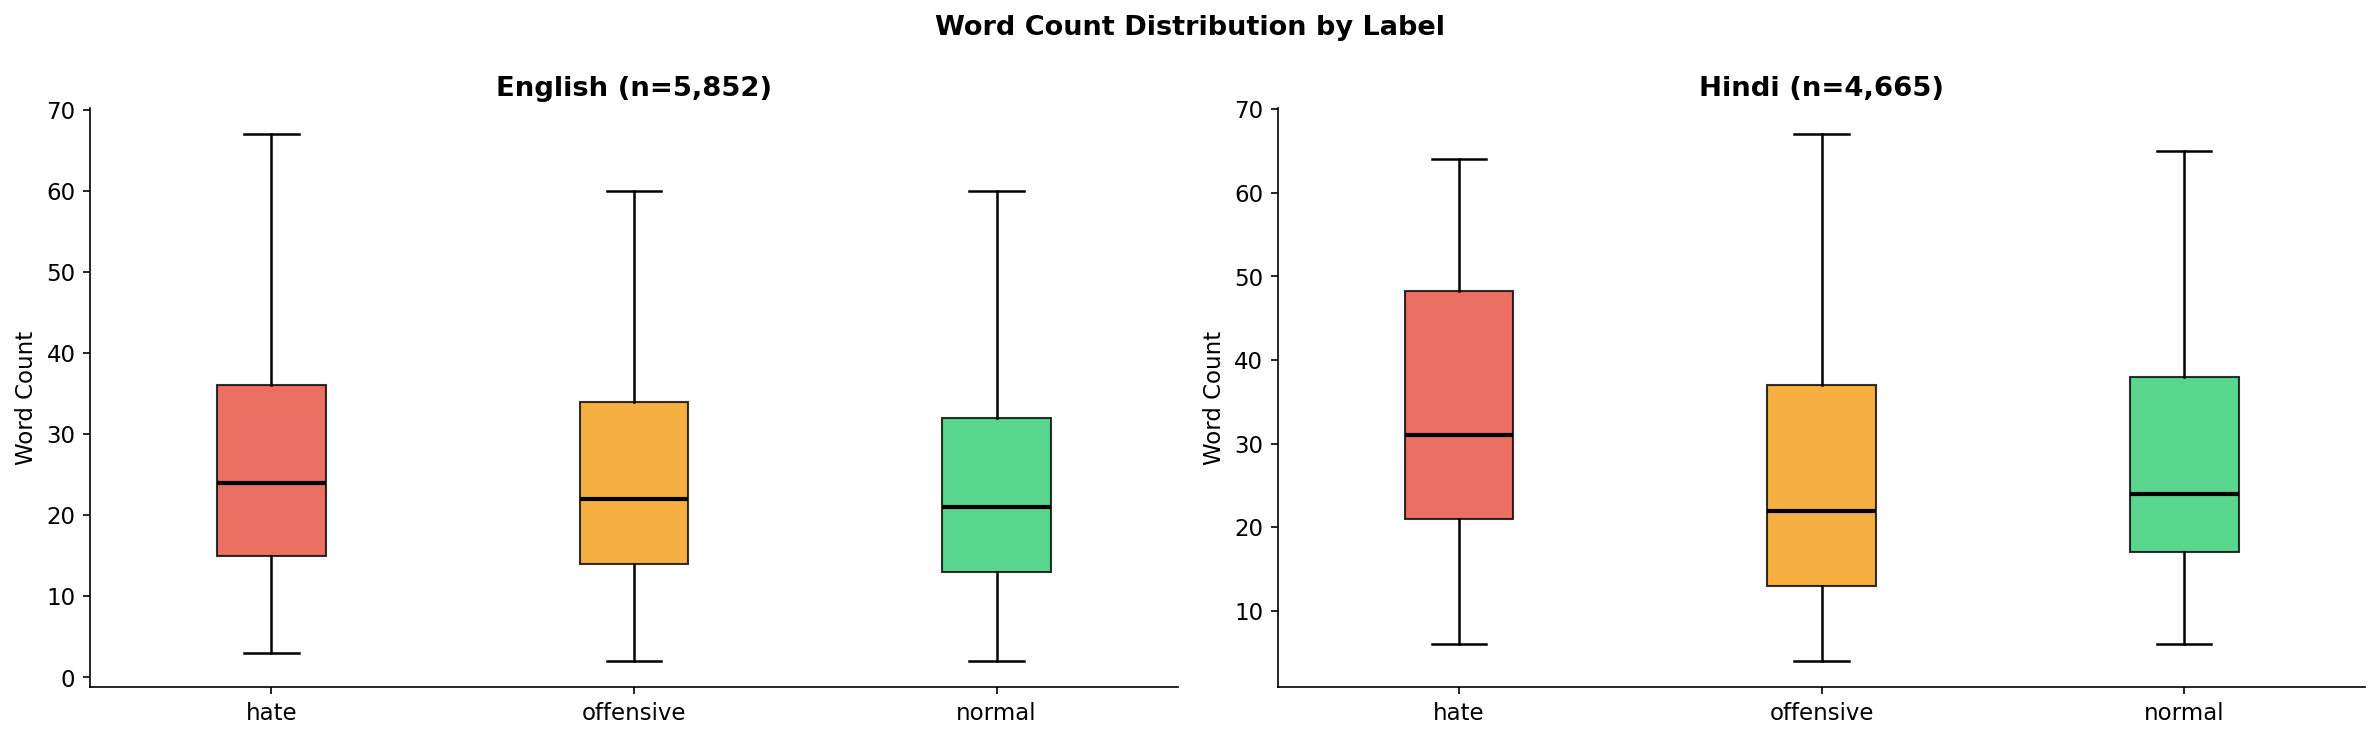

✓ Saved 04_word_count_boxplot.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Word Count Distribution by Label", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, [("English", en), ("Hindi", hi)]):
    groups       = [df[df["ocula_label"] == l]["word_count"].values for l in OCULA_ORDER]
    colors_list  = [CLASS_COLORS[l] for l in OCULA_ORDER]

    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    showfliers=False)
    for patch, color in zip(bp["boxes"], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(OCULA_ORDER)
    ax.set_title(f"{name} (n={len(df):,})", fontweight="bold")
    ax.set_ylabel("Word Count")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/04_word_count_boxplot.png", bbox_inches="tight")
plt.show()
print("✓ Saved 04_word_count_boxplot.png")

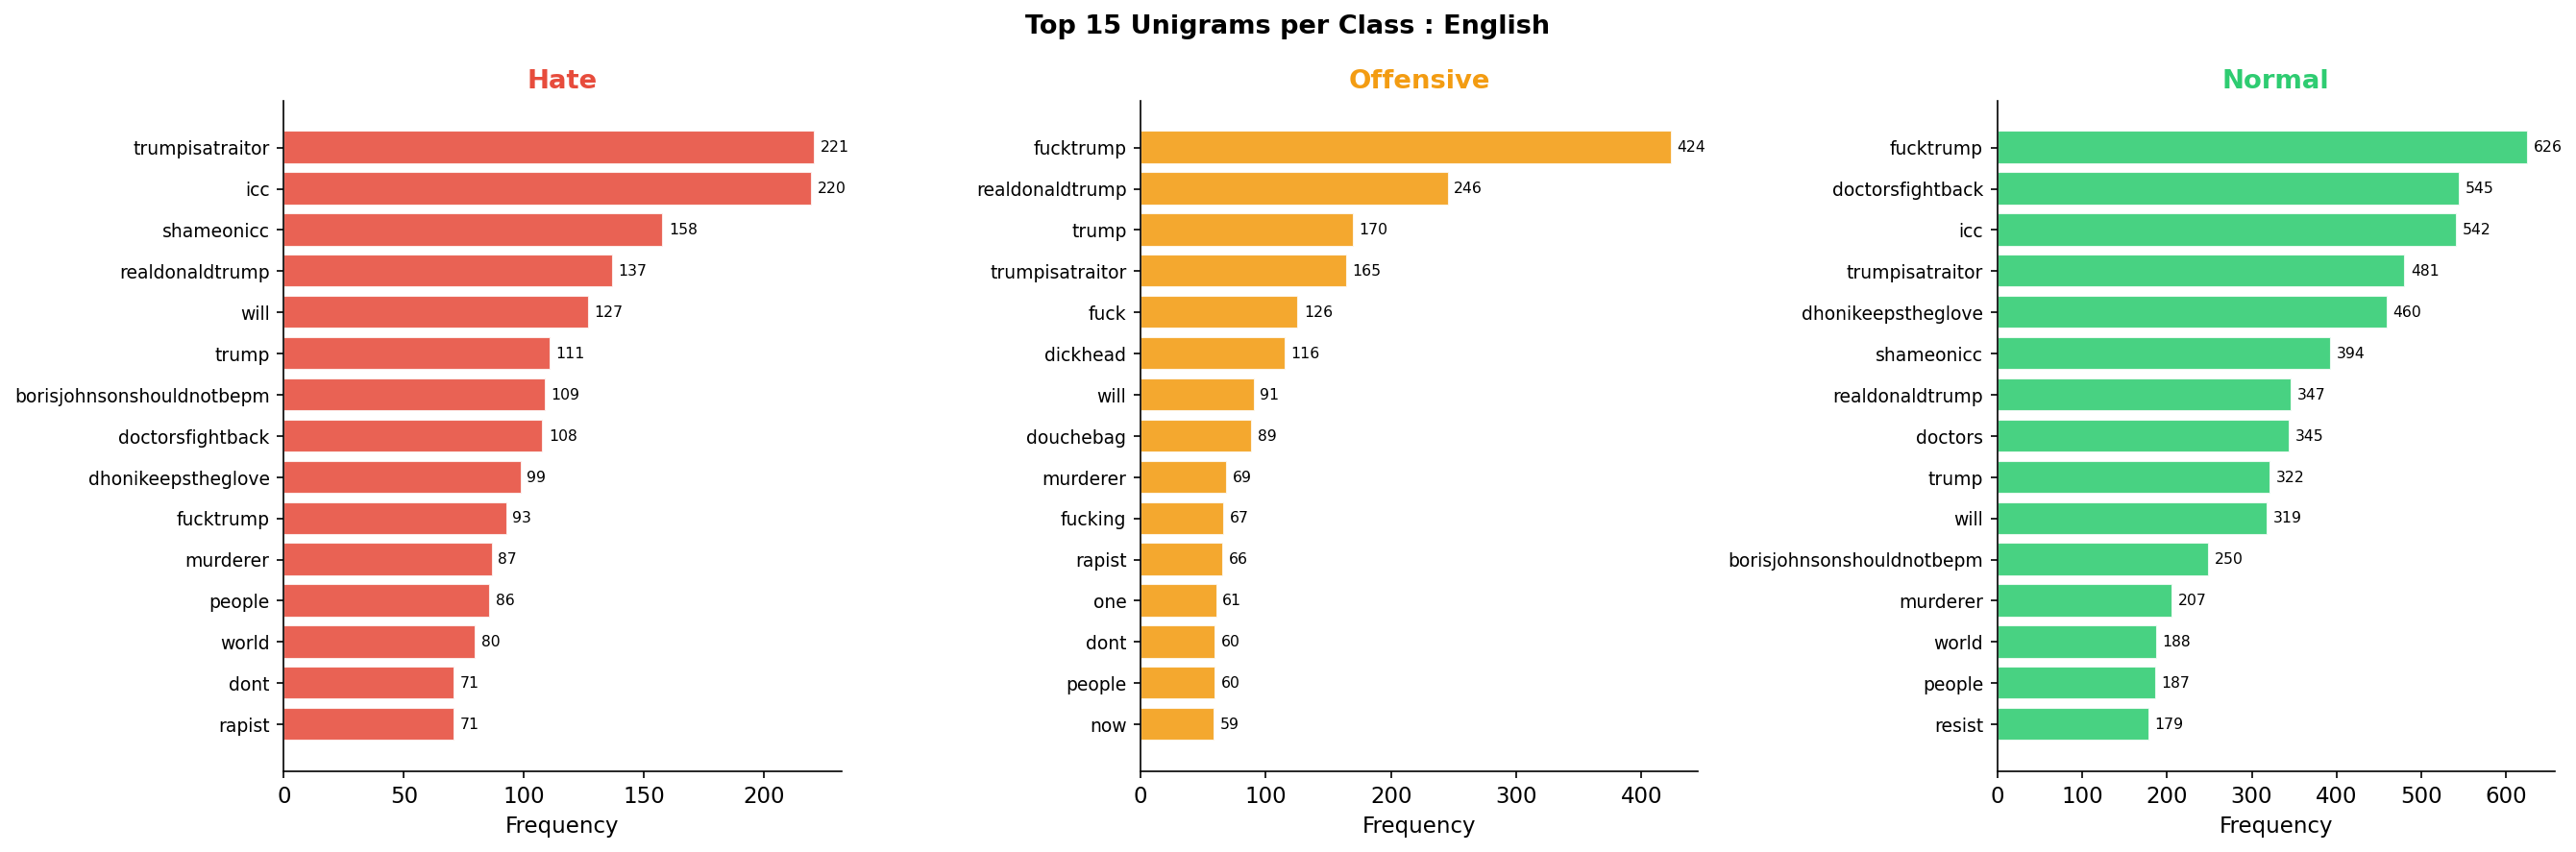

✓ Saved 05_top_unigrams_english.png


In [25]:
def get_top_words(texts, n=15, stopwords=STOPWORDS):
    tokens = []
    for text in texts:
        for tok in re.sub(r"[^\w\s]", "", str(text).lower()).split():
            if tok not in stopwords and len(tok) > 1:
                tokens.append(tok)
    return Counter(tokens).most_common(n)

# English — plot
top_en = {lbl: get_top_words(en[en["ocula_label"] == lbl]["text"]) for lbl in OCULA_ORDER}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top 15 Unigrams per Class : English",
             fontsize=13, fontweight="bold")

for ax, lbl in zip(axes, OCULA_ORDER):
    words, freqs = zip(*top_en[lbl])
    y_pos = np.arange(len(words))
    ax.barh(y_pos, freqs, color=CLASS_COLORS[lbl], edgecolor="white", alpha=0.88)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(lbl.capitalize(), fontweight="bold", color=CLASS_COLORS[lbl])
    ax.set_xlabel("Frequency")
    for i, v in enumerate(freqs):
        ax.text(v + freqs[0]*0.01, i, f"{v:,}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/05_top_unigrams_english.png", bbox_inches="tight")
plt.show()
print("✓ Saved 05_top_unigrams_english.png")

In [27]:
print("=" * 58)
print("  OCULA — HASOC 2019  |  Data Quality Summary")
print("=" * 58)

for name, df in [("English", en), ("Hindi", hi)]:
    total      = len(df)
    dups       = df["text"].duplicated().sum()
    missing    = df["text"].isna().sum()
    vc         = df["ocula_label"].value_counts()
    imbalance  = vc.max() / vc.min() if vc.min() > 0 else float("inf")

    print(f"\n  [{name}]")
    print(f"  Total rows           : {total:>7,}")
    print(f"  Duplicate texts      : {dups:>7,}")
    print(f"  Missing texts        : {missing:>7,}")
    print(f"  Imbalance ratio      : {imbalance:>7.2f}x")
    print(f"  OCULA label distribution:")
    for lbl in OCULA_ORDER:
        cnt = vc.get(lbl, 0)
        print(f"    {lbl:<12}: {cnt:>5,}  ({cnt/total*100:.1f}%)")

    if name == "Hindi":
        print(f"  Script breakdown:")
        sc = df["script_type"].value_counts()
        for stype in ["Devanagari", "Romanized", "Mixed"]:
            cnt = sc.get(stype, 0)
            print(f"    {stype:<12}: {cnt:>5,}  ({cnt/total*100:.1f}%)")

print("\n" + "=" * 58)

  OCULA — HASOC 2019  |  Data Quality Summary

  [English]
  Total rows           :   5,852
  Duplicate texts      :      24
  Missing texts        :       0
  Imbalance ratio      :    3.21x
  OCULA label distribution:
    hate        : 1,143  (19.5%)
    offensive   : 1,118  (19.1%)
    normal      : 3,591  (61.4%)

  [Hindi]
  Total rows           :   4,665
  Duplicate texts      :       0
  Missing texts        :       0
  Imbalance ratio      :    3.95x
  OCULA label distribution:
    hate        :   556  (11.9%)
    offensive   : 1,913  (41.0%)
    normal      : 2,196  (47.1%)
  Script breakdown:
    Devanagari  : 2,428  (52.0%)
    Romanized   :   300  (6.4%)
    Mixed       : 1,937  (41.5%)

